# 0.5.2 — Deep Dive: Central America

Central America ranks **#1 by profit $**. Part of [`0.5_by_region_analysis.ipynb`](0.5_by_region_analysis.ipynb) — see that notebook for how Central America was selected and how it compares to the other 5 regions of interest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def usd(x, pos=None):
    if abs(x) >= 1000:
        return f"${x:,.0f}"
    return f"${x:,.1f}"

USD_FMT = mticker.FuncFormatter(usd)
DATA_DIR = '.'

In [2]:
df_full = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df_full['order date (DateOrders)'] = pd.to_datetime(df_full['order date (DateOrders)'])
df_full['month'] = df_full['order date (DateOrders)'].dt.to_period('M')

df = df_full[df_full['order date (DateOrders)'] < '2017-10-01'].copy()  # exclude Nov-2017+ order-composition artifact (0.1)
print(f"excluded {len(df_full) - len(df):,} rows from Oct 2017 onward ({(len(df_full)-len(df))/len(df_full)*100:.1f}% of {len(df_full):,})")

TOTAL_PROFIT = df['Order Profit Per Order'].sum()
TOTAL_REVENUE = df['Order Item Total'].sum()

def region_row(region):
    sub = df[df['Order Region'] == region]
    profit = sub['Order Profit Per Order'].sum()
    revenue = sub['Order Item Total'].sum()
    return sub, profit, revenue

_all = df.groupby('Order Region').agg(revenue=('Order Item Total', 'sum'), profit=('Order Profit Per Order', 'sum'),
                                       n=('Order Id', 'size')).reset_index()
_all['margin_pct'] = _all['profit'] / _all['revenue'] * 100
_all['margin_rank'] = _all['margin_pct'].rank(ascending=False).astype(int)
_all['profit_rank'] = _all['profit'].rank(ascending=False).astype(int)
_all['pct_of_company_profit'] = _all['profit'] / TOTAL_PROFIT * 100
RANKS = _all.set_index('Order Region')

print(f"transactions: {df.shape[0]:,} rows across {df['Order Region'].nunique()} regions")
print(f"company total: revenue {usd(TOTAL_REVENUE)}, profit {usd(TOTAL_PROFIT)}")

excluded 8,557 rows from Oct 2017 onward (4.7% of 180,519)
transactions: 171,962 rows across 23 regions
company total: revenue $30,774,234, profit $3,685,985


**Data-generation artifact excluded from here on**: rows from Oct 2017 onward are dropped before any revenue/profit/margin figure below is computed — that window is where order composition breaks (`0.1_company_growth.ipynb` §2: every order collapses to 1 line item, order counts and per-order revenue become non-comparable to earlier months). This affects Western Europe, Northern Europe and Southern Europe's *totals* slightly (they're the only ones of the 6 regions here with any activity that late); it has zero effect on Central America, South America, Central Asia, Canada or Southern Africa, whose data ends earlier anyway. `TOTAL_PROFIT`/`TOTAL_REVENUE` (and therefore every `pct_of_company_profit` figure below) are computed on this same excluded basis, company-wide.

## Scorecard

In [3]:
REGION = 'Central America'
sub, profit, revenue = region_row(REGION)
row = RANKS.loc[REGION]
pos = sub[sub['Order Profit Per Order'] >= 0]['Order Profit Per Order'].sum()
neg = sub[sub['Order Profit Per Order'] < 0]['Order Profit Per Order'].sum()
n_neg_lines = (sub['Order Profit Per Order'] < 0).sum()
window_start, window_end = sub['order date (DateOrders)'].min(), sub['order date (DateOrders)'].max()
months_with_orders = sub['month'].nunique()

scorecard = {
    'Revenue': usd(revenue),
    'Net profit': usd(profit),
    'Margin %': f"{row['margin_pct']:.2f}%",
    'Rank by profit $ (of 23)': int(row['profit_rank']),
    'Rank by margin (of 23)': int(row['margin_rank']),
    '% of company profit': f"{row['pct_of_company_profit']:.2f}%",
    'Gross gain (profitable lines)': usd(pos),
    'Gross loss (unprofitable lines)': usd(neg),
    'Unprofitable lines': f"{n_neg_lines:,} of {len(sub):,} ({n_neg_lines/len(sub)*100:.1f}%)",
    'Active window': f"{window_start.date()} -> {window_end.date()}",
    'Months with orders': f"{months_with_orders}",
}
for k, v in scorecard.items():
    print(f"{k:35s} {v}")

Revenue                             $5,093,850
Net profit                          $616,342
Margin %                            12.10%
Rank by profit $ (of 23)            1
Rank by margin (of 23)              12
% of company profit                 16.72%
Gross gain (profitable lines)       $1,212,043
Gross loss (unprofitable lines)     $-595,702
Unprofitable lines                  5,268 of 28,341 (18.6%)
Active window                       2015-01-01 -> 2017-06-13
Months with orders                  11


## Monthly revenue & profit

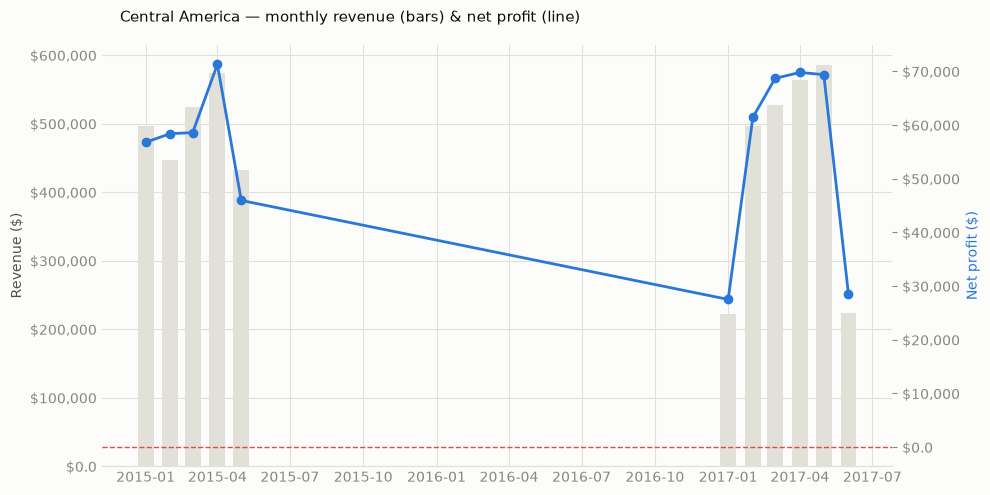

,revenue,profit,n
month,,,
2015-01-01,496540.2,56804.6,2773
2015-02-01,446994.6,58394.7,2508
2015-03-01,524224.9,58594.7,2987
2015-04-01,574461.3,71297.8,3196
2015-05-01,432332.7,45957.8,2493
2017-01-01,222039.6,27516.3,1253
2017-02-01,496969.6,61429.6,2710
2017-03-01,527258.5,68704.3,2963
2017-04-01,564272.3,69798.8,3134


In [4]:
monthly = sub.groupby('month').agg(revenue=('Order Item Total', 'sum'), profit=('Order Profit Per Order', 'sum'), n=('Order Id', 'size'))
monthly.index = monthly.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(monthly.index, monthly['revenue'], width=20, color=GRID, zorder=2, label='Revenue')
ax1.set_ylabel('Revenue ($)')
ax1.yaxis.set_major_formatter(USD_FMT)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['profit'], color=BLUE, marker='o', linewidth=2, zorder=4, label='Net profit')
ax2.axhline(0, color=NEG, linewidth=1, linestyle='--', zorder=3)
ax2.set_ylabel('Net profit ($)', color=BLUE)
ax2.yaxis.set_major_formatter(USD_FMT)
ax2.grid(False)
fig.suptitle(f'{REGION} — monthly revenue (bars) & net profit (line)', x=0.125, ha='left', color=INK, fontsize=11)
style_axis(ax1, x_grid=False, y_grid=True)
plt.tight_layout()
plt.show()
monthly.round(1)

Strong and steady Jan–May 2015 (~$45K–71K profit/month), then a **19-month dead zone with zero recorded orders** (Jun 2015 – Dec 2016), then a full recovery Jan–Jun 2017 back to $61K–70K/month. Profit never goes negative in any month with data.

## Gross gains vs. gross losses

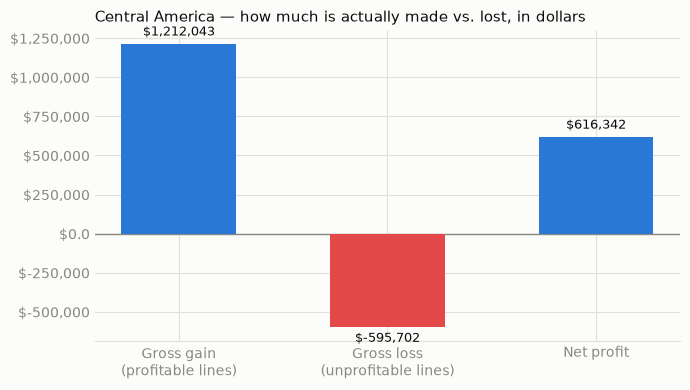

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Gross gain\n(profitable lines)', 'Gross loss\n(unprofitable lines)', 'Net profit']
values = [pos, neg, profit]
colors = [POS, NEG, BLUE]
bars = ax.bar(labels, values, color=colors, zorder=3, width=0.55)
ax.axhline(0, color=INK_MUTED, linewidth=1, zorder=2)
ax.yaxis.set_major_formatter(USD_FMT)
for b, v in zip(bars, values):
    ax.annotate(usd(v), (b.get_x() + b.get_width() / 2, v), ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=9, color=INK, xytext=(0, 4 if v >= 0 else -4), textcoords='offset points')
ax.set_title(f'{REGION} — how much is actually made vs. lost, in dollars', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=False, y_grid=True)
plt.tight_layout()
plt.show()

## Profit $ by category

1 categories with net negative profit in Central America (any n):
                 profit  revenue   n
Category Name                       
As Seen on  TV!  -204.8   4771.5  15


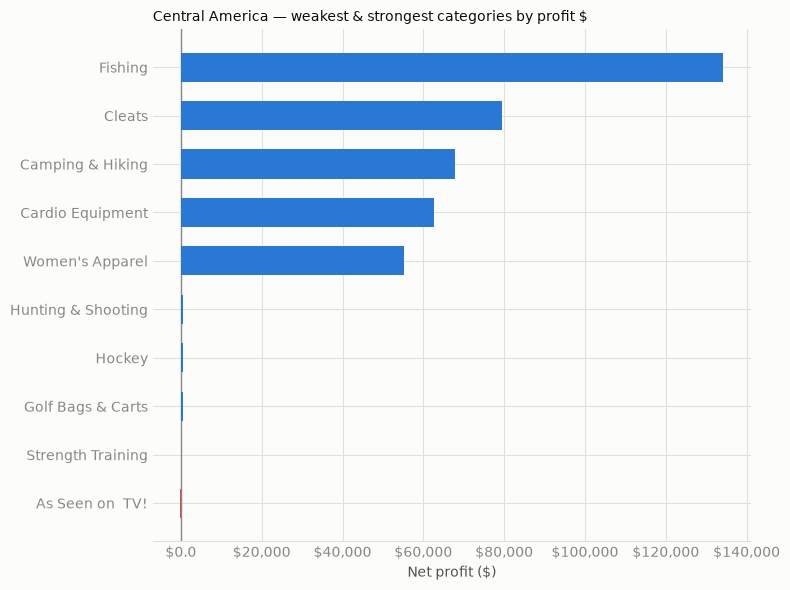

In [6]:
cat_all = sub.groupby('Category Name').agg(profit=('Order Profit Per Order', 'sum'), revenue=('Order Item Total', 'sum'), n=('Order Id', 'size')).sort_values('profit')
neg_cats = cat_all[cat_all['profit'] < 0]
print(f"{len(neg_cats)} categories with net negative profit in {REGION} (any n):")
print(neg_cats.round(1)) if len(neg_cats) else print('  none')

cat = cat_all[cat_all['n'] >= 5]
top_bottom = pd.concat([cat.head(5), cat.tail(5)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top_bottom))
colors = [NEG if v < 0 else POS for v in top_bottom['profit']]
ax.barh(y, top_bottom['profit'], color=colors, zorder=3, height=0.6)
ax.set_yticks(y); ax.set_yticklabels(top_bottom.index)
ax.axvline(0, color=INK_MUTED, linewidth=1, zorder=2)
ax.xaxis.set_major_formatter(USD_FMT)
ax.set_xlabel('Net profit ($)')
ax.set_title(f'{REGION} — weakest & strongest categories by profit $', loc='left', color=INK, fontsize=10)
style_axis(ax, x_grid=True, y_grid=False)
plt.tight_layout()
plt.show()

## How this region stacks up against the other 5

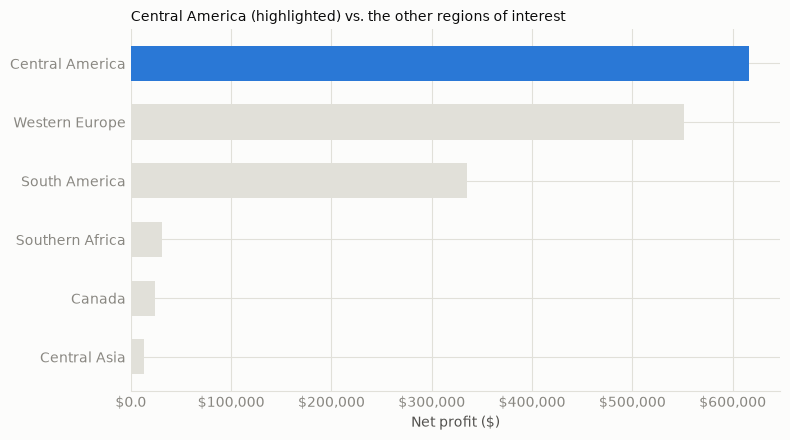

In [7]:
OF_INTEREST = ['Western Europe', 'Central America', 'South America', 'Central Asia', 'Canada', 'Southern Africa']
compare = RANKS.loc[OF_INTEREST, ['profit', 'margin_pct', 'margin_rank', 'profit_rank']].sort_values('profit', ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [BLUE if r_ == REGION else GRID for r_ in compare.index]
y = np.arange(len(compare))
ax.barh(y, compare['profit'], color=colors, zorder=3, height=0.6)
ax.set_yticks(y); ax.set_yticklabels(compare.index)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(USD_FMT)
ax.set_xlabel('Net profit ($)')
ax.set_title(f'{REGION} (highlighted) vs. the other regions of interest', loc='left', color=INK, fontsize=10)
style_axis(ax, x_grid=True, y_grid=False)
plt.tight_layout()
plt.show()

**Bottom line for Central America:** the #1 profit contributor ($616K, 16.7% of company profit) on a healthy 12.1% margin — genuinely the strongest all-around region in this set of 6, with no loss months and only one negligible negative category (As Seen on TV!, -$205 on 15 lines). Its only real caveat is the same one every region in this dataset shares: 19 months with no orders at all in the middle of its window, shared almost exactly with South America (same LATAM market).